In [1]:
import sqlite3
import pandas as pd

# Loaded raw CSV
df = pd.read_csv('team_traditional.csv')

# Create a SQLite database file and connect to it
conn = sqlite3.connect('capstone.db')

# Write the dataframe into a table in that database
df.to_sql('team_traditional', conn, if_exists='replace', index=False)

73404

In [2]:
query = "SELECT * FROM team_traditional WHERE season = 2025 AND type = 'regular'"
df_2025 = pd.read_sql(query, conn)

print(len(df_2025))
df_2025.head()

2460


,gameid,date,type,teamid,team,home,away,MIN,PTS,FGM,...,DREB,REB,AST,TOV,STL,BLK,PF,+/-,win,season
0,22400061,2024-10-22,regular,1610612738,BOS,BOS,NYK,48.0,132.0,48.0,...,29.0,40.0,33.0,4.0,6.0,3.0,15.0,23.0,1.0,2025
1,22400061,2024-10-22,regular,1610612752,NYK,BOS,NYK,48.0,109.0,43.0,...,29.0,34.0,20.0,12.0,2.0,3.0,12.0,-23.0,0.0,2025
2,22400062,2024-10-22,regular,1610612747,LAL,LAL,MIN,48.0,110.0,42.0,...,31.0,46.0,22.0,7.0,7.0,8.0,22.0,7.0,1.0,2025
3,22400062,2024-10-22,regular,1610612750,MIN,LAL,MIN,48.0,103.0,35.0,...,35.0,47.0,17.0,16.0,4.0,1.0,22.0,-7.0,0.0,2025
4,22400063,2024-10-23,regular,1610612754,IND,DET,IND,48.0,115.0,42.0,...,32.0,39.0,32.0,15.0,10.0,8.0,23.0,6.0,1.0,2025


In [10]:
# Check missing values for every column
df_2025.isnull().sum()

,0
gameid,0
date,0
type,0
teamid,0
team,0
home,0
away,0
MIN,0
PTS,0
FGM,0


In [4]:
df_2025.describe()

,gameid,teamid,MIN,PTS,FGM,FGA,FG%,3PM,3PA,3P%,...,DREB,REB,AST,TOV,STL,BLK,PF,+/-,win,season
count,2.460000e+03,2.460000e+03,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,...,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.000000,2460.00000,2460.000000,2460.0
mean,2.240062e+07,1.610613e+09,48.260163,113.825203,41.693496,89.238618,46.822236,13.538211,37.582927,35.989309,...,32.993089,44.112195,26.549593,14.298374,8.204878,4.876016,18.595935,0.00000,0.500000,2025.0
std,3.551425e+02,8.657201e+00,1.181650,12.711950,5.266732,7.290212,5.433185,3.954880,7.033588,8.062669,...,5.423087,6.725460,5.288003,4.027811,3.089734,2.457047,4.204045,15.96616,0.500102,0.0
min,2.240000e+07,1.610613e+09,48.000000,67.000000,22.000000,67.000000,29.300000,3.000000,12.000000,9.500000,...,16.000000,23.000000,9.000000,3.000000,1.000000,0.000000,5.000000,-59.00000,0.000000,2025.0
25%,2.240031e+07,1.610613e+09,48.000000,105.000000,38.000000,84.000000,43.000000,11.000000,33.000000,30.600000,...,29.000000,39.000000,23.000000,11.000000,6.000000,3.000000,16.000000,-10.00000,0.000000,2025.0
50%,2.240062e+07,1.610613e+09,48.000000,114.000000,42.000000,89.000000,46.800000,13.000000,37.000000,35.800000,...,33.000000,44.000000,26.000000,14.000000,8.000000,5.000000,18.000000,0.00000,0.500000,2025.0
75%,2.240092e+07,1.610613e+09,48.000000,122.000000,45.000000,94.000000,50.600000,16.000000,42.000000,41.300000,...,37.000000,48.000000,30.000000,17.000000,10.000000,6.000000,21.000000,10.00000,1.000000,2025.0
max,2.240123e+07,1.610613e+09,58.000000,162.000000,60.000000,119.000000,68.900000,29.000000,63.000000,68.000000,...,52.000000,73.000000,48.000000,31.000000,22.000000,18.000000,35.000000,59.00000,1.000000,2025.0


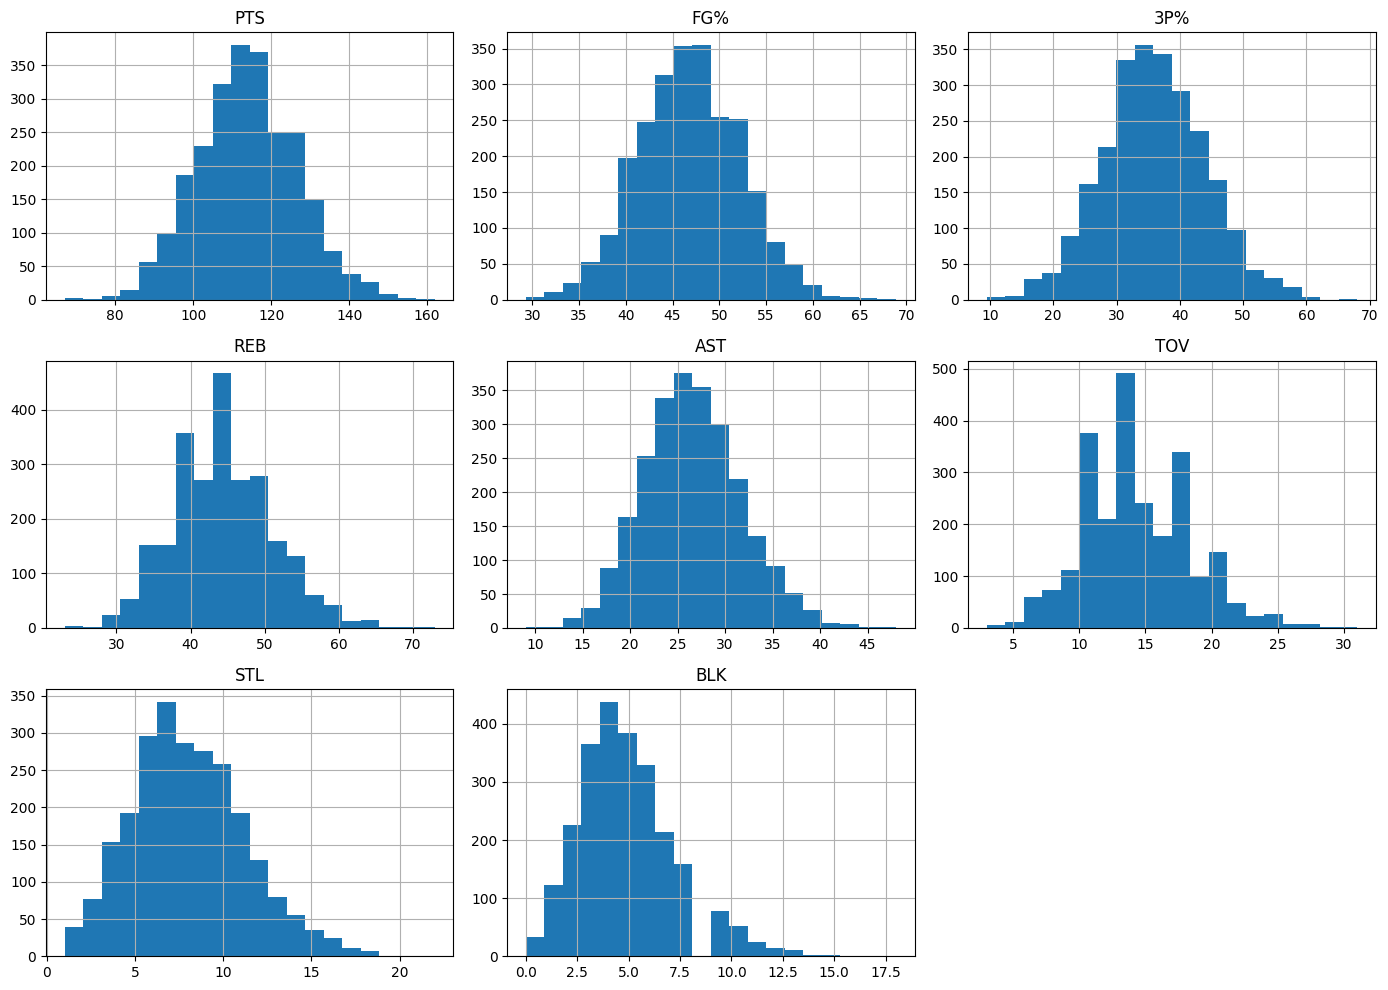

In [5]:

import matplotlib.pyplot as plt

stats = ['PTS', 'FG%', '3P%', 'REB', 'AST', 'TOV', 'STL', 'BLK']

df_2025[stats].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

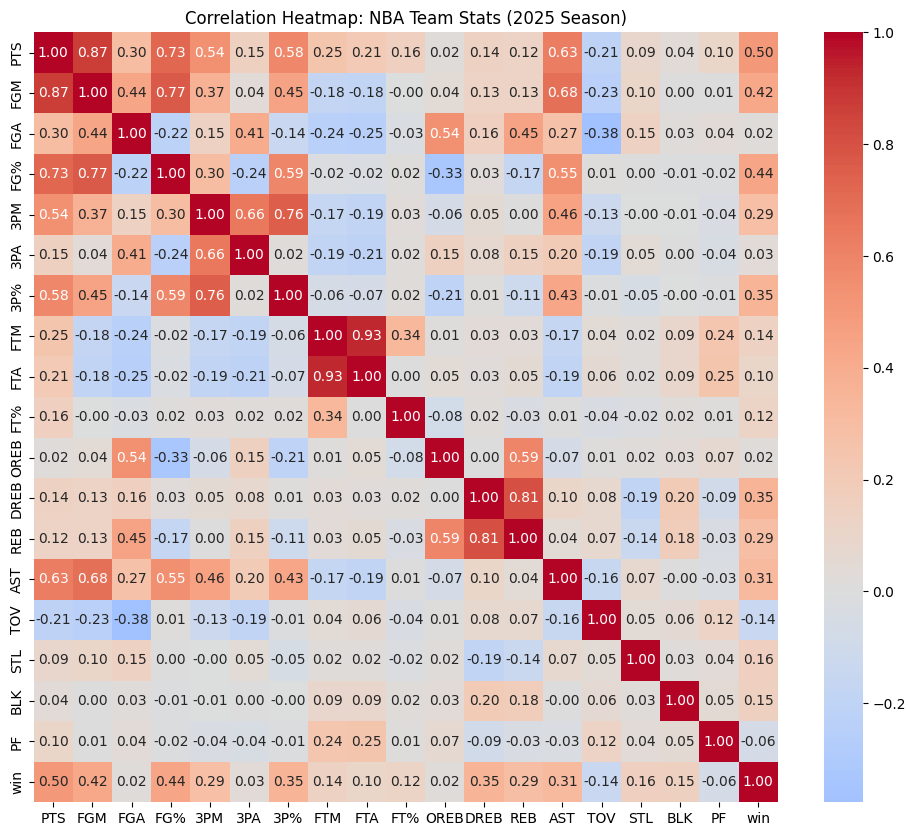

In [6]:
import seaborn as sns

statistics = ['PTS', 'FGM', 'FGA', 'FG%', '3PM', '3PA', '3P%', 'FTM', 'FTA', 'FT%',
                 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF', 'win']

plt.figure(figsize=(12, 10))
sns.heatmap(df_2025[statistics].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: NBA Team Stats (2025 Season)')
plt.show()

In [7]:
conn.close()